In [1]:
import numpy as np
from scipy.stats import gamma, gaussian_kde
import seaborn as sns
from generating_dataset import dataset
from palette import palette
import matplotlib.pyplot as plt
from utils_lasso import standarized_centered_X_y, bayesian_lasso_hyp

In [2]:
X,y = dataset
n,p = X.shape[0],X.shape[1]-1
X_stdized,y_tilde = standarized_centered_X_y(X,y)

### <b> EXPERIMENT 7.4.1.2. Hyperprior Bayesian Lasso

In [3]:
XtX_inv = np.linalg.pinv(X.T @ X)
beta_0 = XtX_inv @ X.T @ y_tilde
residuals_ols = y_tilde - X @ beta_0

sigma2_0 = (residuals_ols.T @ residuals_ols) / (n - p)
sum_abs_beta = np.sum(np.abs(beta_0))
lambda_0 = (p * np.sqrt(sigma2_0)) / sum_abs_beta
lambda_sq_0 = lambda_0**2

In [4]:
lambda_0 = np.sqrt(lambda_sq_0)

In [5]:
results_hyp = bayesian_lasso_hyp(y_tilde,X_stdized,r=1,delta=1/(lambda_0**2))

### <b> Lambda distribution

In [ ]:
lambda_samples = np.sqrt(results_hyp['lambda_sq'])
lambda_median = np.median(lambda_samples)
lambda_mean = np.mean(lambda_samples)


ci_lower = np.percentile(lambda_samples, 2.5)
ci_upper = np.percentile(lambda_samples, 97.5)
kde = gaussian_kde(lambda_samples)
x_range = np.linspace(min(lambda_samples), max(lambda_samples), 1000)
lambda_mode = x_range[np.argmax(kde(x_range))]

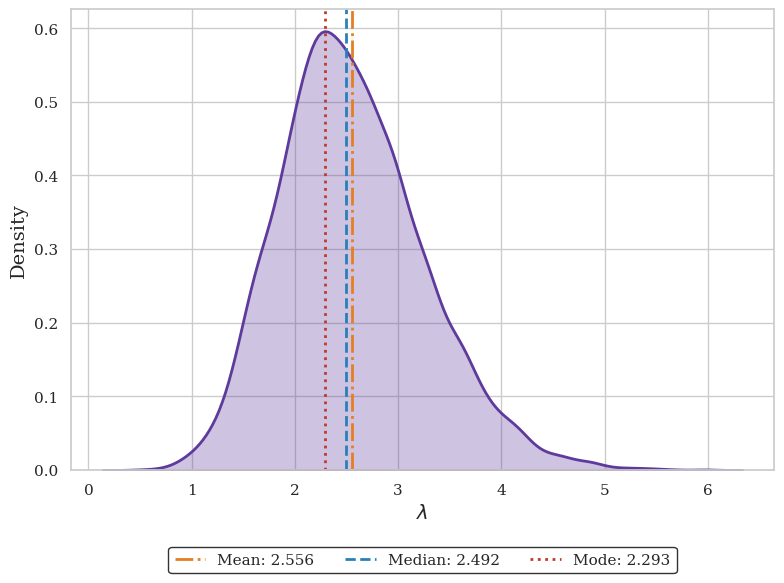

In [7]:
sns.set_theme(style="whitegrid", font="serif")
fig, ax = plt.subplots(figsize=(8, 6))
main_color = palette.lasso_hyp 
sns.kdeplot(lambda_samples, fill=True, color=main_color, alpha=0.3, linewidth=2, ax=ax)
ax.axvline(lambda_mean, color="#e67e22", linestyle="-.", linewidth=2, label=f'Mean: {lambda_mean:.3f}')
ax.axvline(lambda_median, color="#2980b9", linestyle="--", linewidth=2, label=f'Median: {lambda_median:.3f}')
ax.axvline(lambda_mode, color="#c0392b", linestyle=":", linewidth=2, label=f'Mode: {lambda_mode:.3f}')
ax.set_xlabel(r"$\lambda$", fontsize=14)
ax.set_ylabel("Density", fontsize=14)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
          ncol=3, fontsize=11, frameon=True, edgecolor='black')
plt.tight_layout()
plt.savefig("../graphics/lambda_posterior_hyp_lasso.pdf", dpi=300, bbox_inches='tight')
plt.show()